In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pickle

In [2]:
df = pd.read_csv("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/PCA_26개컬럼.csv")
X = df.drop(columns=['Segment'])
y = df['Segment']

In [3]:
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['Segment'], random_state=42)

In [4]:
model_e = xgb.XGBClassifier()
model_e.load_model("model/best_model_classification_e_vs_not_e_26.dat")

# 학습 데이터 예측
X_train = df_train.drop(columns=['Segment'])
pred_E_train = model_e.predict(X_train)
proba_E_train = model_e.predict_proba(X_train)

df_train['pred_E'] = pred_E_train
df_train['proba_E'] = proba_E_train[:, 1]

# 테스트 데이터 예측
X_test = df_test.drop(columns=['Segment'])
pred_E_test = model_e.predict(X_test)
proba_E_test = model_e.predict_proba(X_test)

df_test['pred_E'] = pred_E_test
df_test['proba_E'] = proba_E_test[:, 1]

In [5]:
model_abcd = xgb.XGBClassifier()
model_abcd.load_model("model/best_model_classification_up_downsampling_26.dat")

# 학습 데이터 중 Not E만 예측
not_e_idx_train = df_train[df_train['pred_E'] == 0].index
X_not_e_train = X_train.loc[not_e_idx_train]

pred_ABCD_train = model_abcd.predict(X_not_e_train)
proba_ABCD_train = model_abcd.predict_proba(X_not_e_train)

df_train.loc[not_e_idx_train, 'pred_ABCD'] = pred_ABCD_train
df_train.loc[not_e_idx_train, ['proba_A', 'proba_B', 'proba_C', 'proba_D']] = proba_ABCD_train

# 테스트 데이터 중 Not E만 예측
not_e_idx_test = df_test[df_test['pred_E'] == 0].index
X_not_e_test = X_test.loc[not_e_idx_test]

pred_ABCD_test = model_abcd.predict(X_not_e_test)
proba_ABCD_test = model_abcd.predict_proba(X_not_e_test)

df_test.loc[not_e_idx_test, 'pred_ABCD'] = pred_ABCD_test
df_test.loc[not_e_idx_test, ['proba_A', 'proba_B', 'proba_C', 'proba_D']] = proba_ABCD_test

In [6]:
# 결측치 채우기 (E로 분류된 애들은 ABCD 확률 없음)
df_train.fillna(0, inplace=True)
df_test.fillna(0, inplace=True)

In [7]:
# 원본 컬럼 리스트
original_cols = [col for col in df_train.columns if col not in ['pred_E', 'proba_E', 'proba_A', 'proba_B', 'proba_C', 'proba_D', 'Segment']]
feature_cols = original_cols + ['pred_E', 'proba_E', 'proba_A', 'proba_B', 'proba_C', 'proba_D']

# 학습 데이터, 테스트 데이터 준비
X_final_train = df_train[feature_cols]
X_final_test = df_test[feature_cols]

le = LabelEncoder()
y_final_train = le.fit_transform(df_train['Segment'])
y_final_test = le.transform(df_test['Segment'])

# 모델 학습
final_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, random_state=42)
final_model.fit(X_final_train, y_final_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
              objective='multi:softprob', predictor=None, ...)

In [8]:
y_pred = final_model.predict(X_final_test)
y_pred_labels = le.inverse_transform(y_pred)
y_true_labels = df_test['Segment']

print("Accuracy:", accuracy_score(y_true_labels, y_pred_labels))
print("F1 Score (micro):", f1_score(y_true_labels, y_pred_labels, average='micro'))
print("F1 Score (macro):", f1_score(y_true_labels, y_pred_labels, average='macro'))
print("Classification Report:\n", classification_report(y_true_labels, y_pred_labels))

Accuracy: 0.8853458333333334
F1 Score (micro): 0.8853458333333335
F1 Score (macro): 0.6725209260747939
Classification Report:
               precision    recall  f1-score   support

           A       0.76      0.46      0.57       194
           B       0.63      0.59      0.61        29
           C       0.69      0.54      0.60     25518
           D       0.65      0.62      0.63     69848
           E       0.94      0.96      0.95    384411

    accuracy                           0.89    480000
   macro avg       0.73      0.63      0.67    480000
weighted avg       0.88      0.89      0.88    480000



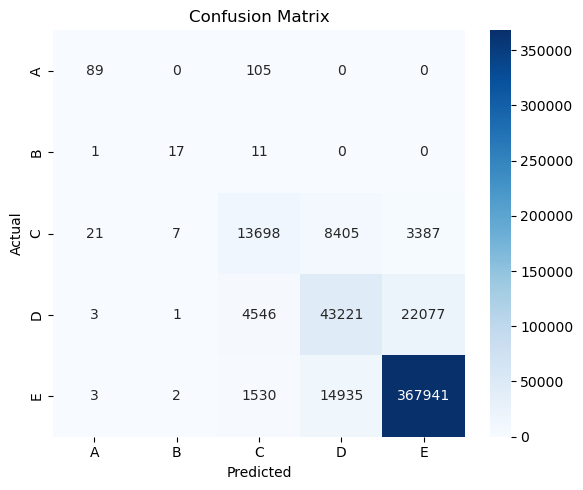

In [9]:
# 혼동 행렬
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=le.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

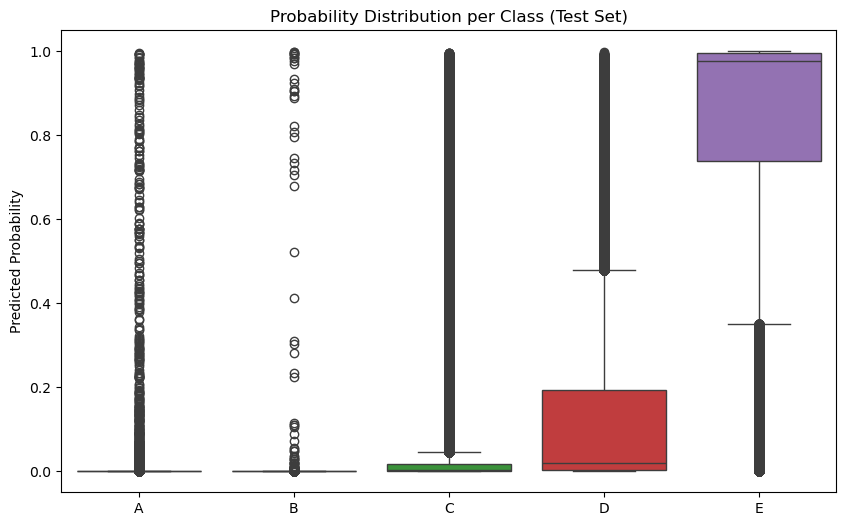

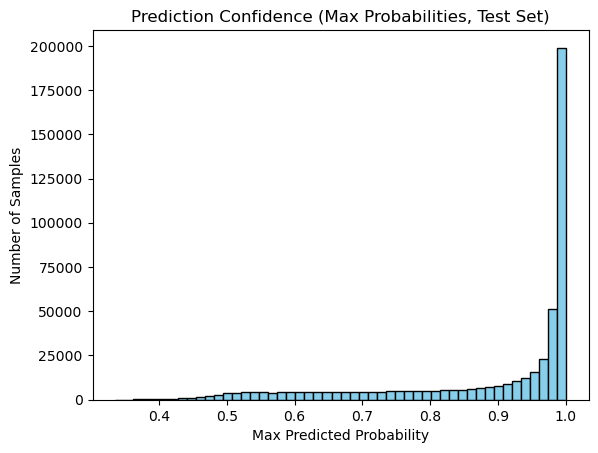

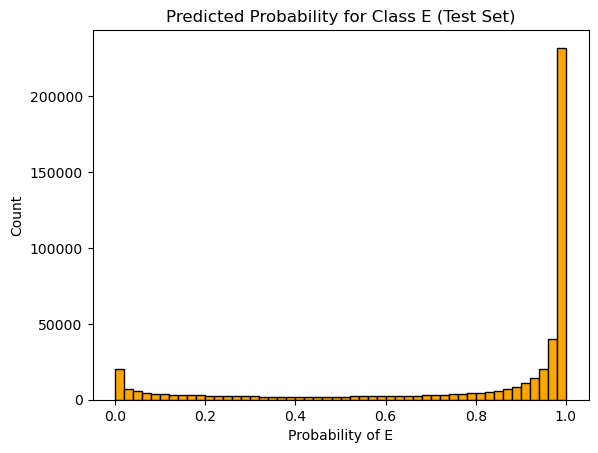

In [10]:
# 시각화

y_proba_test = final_model.predict_proba(X_final_test)
proba_df = pd.DataFrame(y_proba_test, columns=le.classes_)

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=proba_df)
plt.title("Probability Distribution per Class (Test Set)")
plt.ylabel("Predicted Probability")
plt.show()

# Max 확률 히스토그램
proba_df['max_proba'] = proba_df.max(axis=1)
plt.hist(proba_df['max_proba'], bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence (Max Probabilities, Test Set)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Number of Samples")
plt.show()

# E 클래스 확률 히스토그램
plt.hist(proba_df['E'], bins=50, color='orange', edgecolor='black')
plt.title("Predicted Probability for Class E (Test Set)")
plt.xlabel("Probability of E")
plt.ylabel("Count")
plt.show()


In [11]:
# 모델저장하기
final_model.save_model("model/final_model_2hi.dat")

# 라벨 인코더 저장
with open("model/label_encoder_2hi.pkl", "wb") as f:
    pickle.dump(le, f)